In [2]:
import xarray 
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.cm as cm
jet = cm.get_cmap('jet', 256)
newcolors = jet(np.linspace(0.2, 1.0, 256))  # skip darkest 20%
lighter_jet = ListedColormap(newcolors)

/tmp/ipykernel_2613419/1587183914.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap('jet', 256)


In [ ]:
mon = 10
day = 3
file_pattern = 'curtain_tracks/p3_2019-'
file_paths = [f'{mon:02}-{day:02}-03600_day1_track_MUSICAv0_7km_CAMP2Ex.nc', f'{mon:02}-{day+1:02}-03600_day2_track_MUSICAv0_7km_CAMP2Ex.nc']
full_file_paths = [file_pattern + file_path for file_path in file_paths]
ds = xarray.open_mfdataset(full_file_paths, combine='by_coords')
variables = ['xco', 'yco','zco', 'u_mod', 'v_mod', 'pom_mod', 'soa_mod','so4_mod', 'bc_mod','pblh_mod']
selected_data = ds[variables]
musicav0data = selected_data.to_dataframe().reset_index()

musicav0data['wdir'] = np.degrees(np.arctan2(musicav0data['v_mod'],musicav0data['u_mod']))
musicav0data['wdir'] = (270 - musicav0data['wdir']) % 360

musicav0data['lon'] = musicav0data['xco']
musicav0data['lat'] = musicav0data['yco']
musicav0data['alt'] = musicav0data['zco']
musicav0data['datetime'] = pd.to_datetime(musicav0data['datetime'])
musicav0data_ = musicav0data[(musicav0data['datetime'] >= '2019-10-04 02:32:00') & (musicav0data['datetime'] <= '2019-10-04 02:48:00')]
musicav0data_xy_Control = musicav0data_
musicav0data_xy_Control
wind_Control = musicav0data

In [ ]:
mon = 10
day = 3
file_pattern = 'curtain_tracks_Exp01/p3_2019-'
file_paths = [f'{mon:02}-{day:02}-03600_day1_track_MUSICAv0_7km_CAMP2Ex.nc', f'{mon:02}-{day+1:02}-03600_day2_track_MUSICAv0_7km_CAMP2Ex.nc']
full_file_paths = [file_pattern + file_path for file_path in file_paths]
ds = xarray.open_mfdataset(full_file_paths, combine='by_coords')
variables = ['xco', 'yco','zco', 'u_mod', 'v_mod', 'pom_mod', 'soa_mod','so4_mod', 'bc_mod','pblh_mod']
selected_data = ds[variables]
musicav0data = selected_data.to_dataframe().reset_index()

musicav0data['wdir'] = np.degrees(np.arctan2(musicav0data['v_mod'],musicav0data['u_mod']))
musicav0data['wdir'] = (270 - musicav0data['wdir']) % 360

musicav0data['lon'] = musicav0data['xco']
musicav0data['lat'] = musicav0data['yco']
musicav0data['alt'] = musicav0data['zco']
musicav0data['datetime'] = pd.to_datetime(musicav0data['datetime'])
musicav0data_ = musicav0data[(musicav0data['datetime'] >= '2019-10-04 02:32:00') & (musicav0data['datetime'] <= '2019-10-04 02:48:00')]
musicav0data_xy_Exp01 = musicav0data_
wind_Exp01 = musicav0data


In [ ]:
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cf

import numpy as np
osm_tiles = cimgt.OSM()
def plot_background(ax):
    ax.add_feature(cf.COASTLINE.with_scale('10m'),facecolor="None",edgecolor="k", linewidth=1)
    ax.add_feature(cf.LAKES.with_scale('10m'), facecolor = 'None', edgecolor='k')

ylo = 5
yhi = 19
xlo = 115
xhi = 127

def plot_ticks(ax):
    ax.set_yticks(np.arange(ylo,yhi,1), crs = ccrs.PlateCarree())
    ax.set_xticks(np.arange(xlo,xhi,1), crs = ccrs.PlateCarree())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.xaxis.set_major_formatter(LongitudeFormatter())

In [6]:
dat = '20191003'
dat1 = '2019-10-03-03600'
dat2 = '2019-10-04-03600'
workdir = '/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)
p3data_ds

<xarray.Dataset>
Dimensions:                       (time: 15016, bnds: 2, SMPS_Bin: 30,
                                   FIMS_Bin: 30, LAS_Bin: 26, APS_Bin: 13,
                                   WL_RSP1: 10, WL_SSFR: 12)
Coordinates:
  * time                          (time) datetime64[ns] 2019-10-03T22:55:09.5...
    lat                           (time) float32 ...
    lon                           (time) float32 ...
    alt                           (time) float32 ...
  * SMPS_Bin                      (SMPS_Bin) float32 0.003162 ... 0.08913
  * FIMS_Bin                      (FIMS_Bin) float32 10.0 11.52 ... 521.0 600.0
  * LAS_Bin                       (LAS_Bin) float32 0.1 0.1122 ... 2.512 3.162
  * APS_Bin                       (APS_Bin) float32 0.597 0.669 ... 4.496 5.661
  * WL_RSP1                       (WL_RSP1) float32 410.0 469.0 ... 1.064e+03
  * WL_SSFR                       (WL_SSFR) float32 415.9 439.2 ... 2.101e+03
Dimensions without coordinates: bnds
Data variables: (12/263)
    time_bnds                     (time, bnds) datetime64[ns] ...
    Pressure_Altitude             (time) float32 ...
    Radar_Altitude                (time) float32 ...
    Ground_Speed                  (time) float32 ...
    True_Air_Speed                (time) float32 ...
    Indicated_Air_Speed           (time) float32 ...
    ...                            ...
    kext_f                        (time, WL_RSP1) float32 ...
    kext_c                        (time, WL_RSP1) float32 ...
    p180_f                        (time, WL_RSP1) float32 ...
    p180_c                        (time, WL_RSP1) float32 ...
    Down_shortwave_Irradiance     (time, WL_SSFR) float32 ...
    Up_shortwave_Irradiance       (time, WL_SSFR) float32 ...
Attributes: (12/37)
    conventions:               CF-1.10
    data_use_guideline:        For responsible scientific use of the data set...
    summary:                   Merged Flight#20191003, on the P3B platform. D...
    id:                        10.5067/Airborne/CAMP2Ex_Merge_Data_1
    file_originator:           Michael Shook
    file_originator_contact:   michael.a.shook@nasa.gov
    ...                        ...
    geospatial_lat_max:        15.4693 degrees_north
    geospatial_lat_min:        13.5067 degrees_north
    geospatial_lon_max:        121.8827 degrees_east
    geospatial_lon_min:        120.1323 degrees_east
    time_coverage_resolution:  1.000000 seconds
    references:                Please see data source group attributes for: (...

In [7]:
variables = ['U', 'V', 'WDIR', 'CO', 'CO2', 'SO4_Ave_IsoK_STP', 'Org_Ave_IsoK_STP', 'BlackCarbon_STP', 'mz42_Ave_IsoK_STP', 'mz43_Ave_IsoK_STP', 'mz44_Ave_IsoK_STP', 'mz60_Ave_IsoK_STP']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()

In [ ]:
p3data_ = p3data[(p3data['time'] >= '2019-10-04 02:32:00') & (p3data['time'] <= '2019-10-04 02:48:00')]
p3data_xy = p3data_


/tmp/ipykernel_2613419/1892537899.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p3data_xy['BlackCarbon_STP'] = p3data_xy['BlackCarbon_STP'] * 1e-3


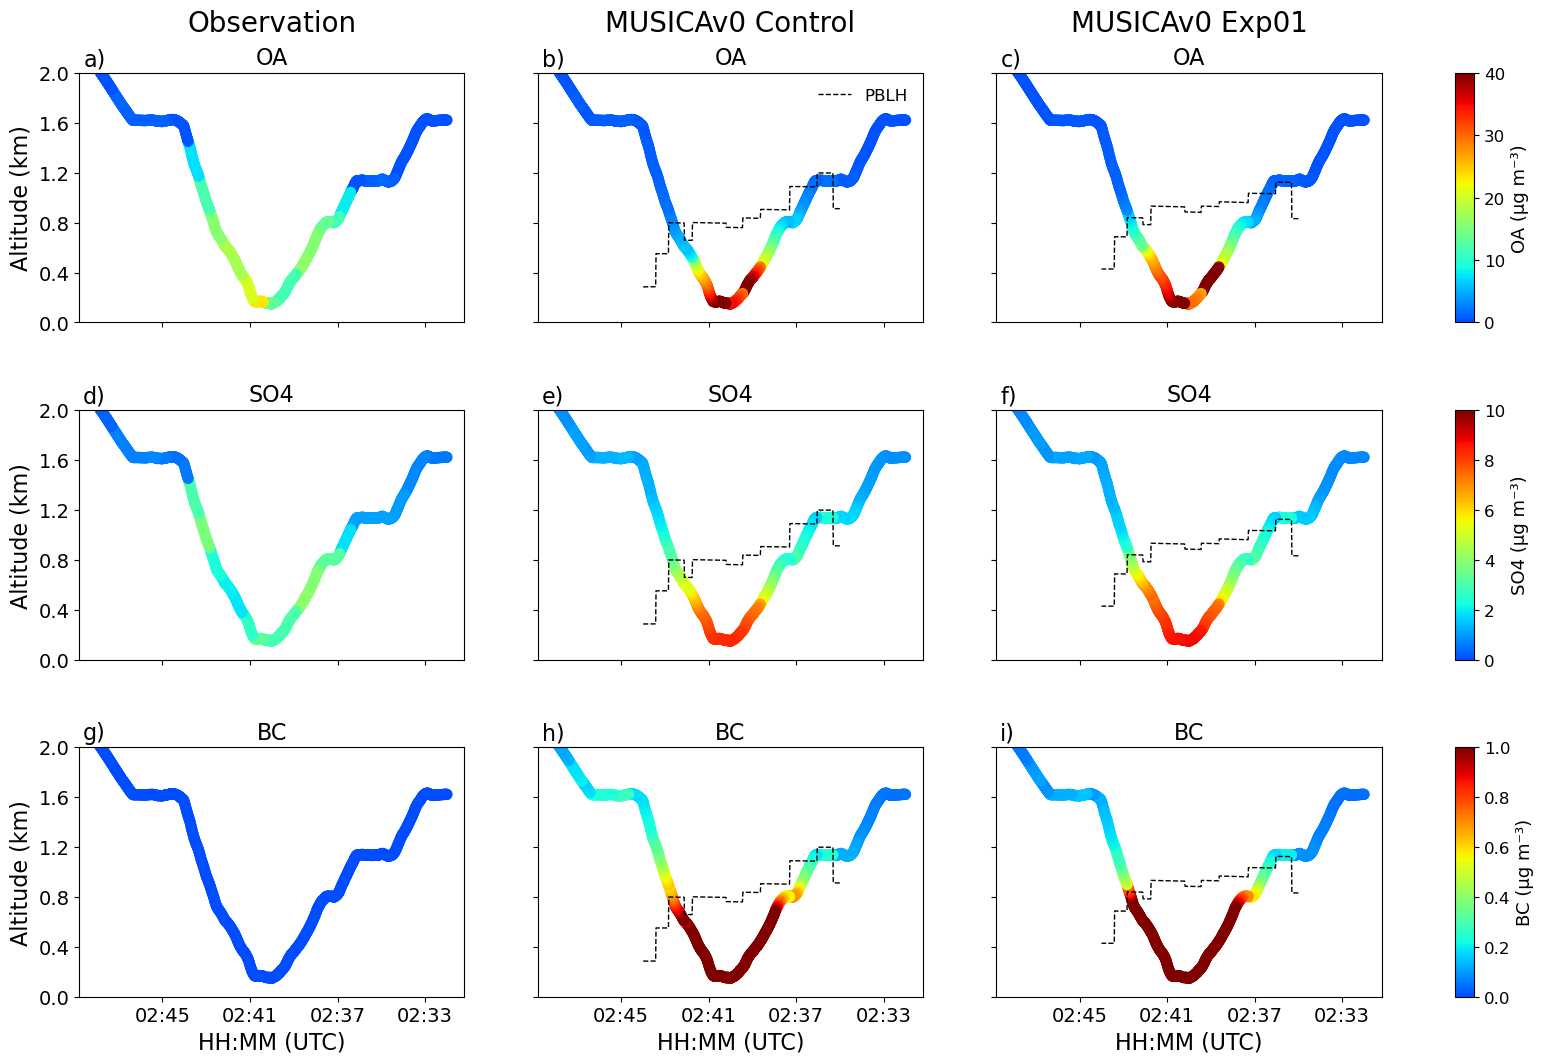

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
import pandas as pd

p3data_xy['BlackCarbon_STP'] = p3data_xy['BlackCarbon_STP'] * 1e-3

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 4, width_ratios=[1, 1, 1, 0.05],
                       hspace=0.35, wspace=0.25)

col_titles = ["Observation", "MUSICAv0 Control", "MUSICAv0 Exp01"]

for c, title in enumerate(col_titles):
    ax_col = fig.add_subplot(gs[0, c])
    ax_col.set_title(title, fontsize=20, pad=30)
    ax_col.set_xticks([])
    ax_col.set_yticks([])
    ax_col.patch.set_alpha(0)
    for spine in ax_col.spines.values():
        spine.set_visible(False)

species = [
    ("OA",  "Org_Ave_IsoK_STP",      lambda d: d["pom_mod"] + d["soa_mod"], 0, 40),
    ("SO4", "SO4_Ave_IsoK_STP",      lambda d: d["so4_mod"],                0, 10),
    ("BC",  "BlackCarbon_STP",       lambda d: d["bc_mod"],                 0, 1)
]

panel_labels = [
    ("a)", "b)", "c)"),
    ("d)", "e)", "f)"),
    ("g)", "h)", "i)")
]

t_start = pd.to_datetime("2019-10-04 02:35")
t_end   = pd.to_datetime("2019-10-04 02:44")

def plot_row(row, labels, title, obs_var, mod_func, vmin, vmax,
             ax_prev=None):

    # ---------------- COLUMN 1: OBS ----------------
    ax_obs = fig.add_subplot(gs[row, 0], sharex=ax_prev[0] if ax_prev else None)
    ax_obs.text(0.01, 1.01, labels[0], transform=ax_obs.transAxes,
                fontsize=16, va='bottom', ha='left')

    sc = ax_obs.scatter(
        p3data_xy["time"],
        p3data_xy["alt"] / 1000,
        c=p3data_xy[obs_var],
        vmin=vmin, vmax=vmax,
        cmap=lighter_jet, s=50
    )

    ax_obs.set_ylim(0, 2)
    ax_obs.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_obs.set_ylabel("Altitude (km)", fontsize=16)
    ax_obs.set_title(f"{title}", fontsize=16)
    ax_obs.tick_params(axis="both", labelsize=14)

    if row < 2:
        ax_obs.tick_params(labelbottom=False)
    else:
        ax_obs.xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
        ax_obs.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax_obs.set_xlabel("HH:MM (UTC)", fontsize=16)

    ax_obs.invert_xaxis()

    # ---------------- COLUMN 2: CONTROL ----------------
    ax_ctrl = fig.add_subplot(gs[row, 1], sharex=ax_prev[1] if ax_prev else None)
    ax_ctrl.text(0.01, 1.01, labels[1], transform=ax_ctrl.transAxes,
                 fontsize=16, va='bottom', ha='left')

    sc = ax_ctrl.scatter(
        musicav0data_xy_Control["datetime"],
        musicav0data_xy_Control["alt"] / 1000,
        c=mod_func(musicav0data_xy_Control),
        vmin=vmin, vmax=vmax,
        cmap=lighter_jet, s=50
    )

    mask_ctrl = (musicav0data_xy_Control["datetime"] >= t_start) & \
                (musicav0data_xy_Control["datetime"] <= t_end)

    ax_ctrl.plot(
        musicav0data_xy_Control["datetime"][mask_ctrl],
        (musicav0data_xy_Control["pblh_mod"][mask_ctrl] / 1000),
        color="black", linewidth=1, linestyle="--", zorder=10,
        label="PBLH"
    )


    ax_ctrl.set_ylim(0, 2)
    ax_ctrl.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_ctrl.tick_params(axis="y", labelleft=False)
    ax_ctrl.set_title(f"{title}", fontsize=16)
    ax_ctrl.tick_params(axis="both", labelsize=14)

    if row < 2:
        ax_ctrl.tick_params(labelbottom=False)
    else:
        ax_ctrl.xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
        ax_ctrl.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax_ctrl.set_xlabel("HH:MM (UTC)", fontsize=16)

    ax_ctrl.invert_xaxis()
    if row == 0:
        ax_ctrl.legend(loc="upper right", fontsize=12, frameon=False)

    # ---------------- COLUMN 3: EXP01 ----------------
    ax_exp = fig.add_subplot(gs[row, 2], sharex=ax_prev[2] if ax_prev else None)
    ax_exp.text(0.01, 1.01, labels[2], transform=ax_exp.transAxes,
                fontsize=16, va='bottom', ha='left')

    sc = ax_exp.scatter(
        musicav0data_xy_Exp01["datetime"],
        musicav0data_xy_Exp01["alt"] / 1000,
        c=mod_func(musicav0data_xy_Exp01),
        vmin=vmin, vmax=vmax,
        cmap=lighter_jet, s=50
    )

    mask_exp = (musicav0data_xy_Exp01["datetime"] >= t_start) & \
               (musicav0data_xy_Exp01["datetime"] <= t_end)

    ax_exp.plot(
    musicav0data_xy_Exp01["datetime"][mask_exp],
    (musicav0data_xy_Exp01["pblh_mod"][mask_exp] / 1000),
    color="black", linewidth=1, linestyle="--", zorder=10
    )


    ax_exp.set_ylim(0, 2)
    ax_exp.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_exp.tick_params(axis="y", labelleft=False)
    ax_exp.set_title(f"{title}", fontsize=16)
    ax_exp.tick_params(axis="both", labelsize=14)

    if row < 2:
        ax_exp.tick_params(labelbottom=False)
    else:
        ax_exp.xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
        ax_exp.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax_exp.set_xlabel("HH:MM (UTC)", fontsize=16)

    ax_exp.invert_xaxis()

    cbar_ax = fig.add_subplot(gs[row, 3])
    cbar = plt.colorbar(sc, cax=cbar_ax, orientation="vertical")
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label(f"{title} (µg m⁻³)", fontsize=13)

    return ax_obs, ax_ctrl, ax_exp

ax_prev = None

for i, ((title, obs_var, mod_func, vmin, vmax), labels) in enumerate(zip(species, panel_labels)):
    ax_prev = plot_row(
        i, labels, title, obs_var, mod_func, vmin, vmax,
        ax_prev=ax_prev
    )
plt.show()
